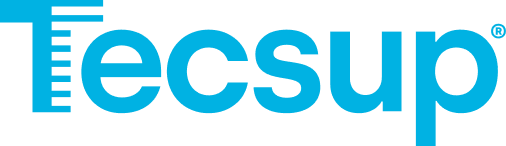

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 12: DISTRIBUCIONES DE PROBABILIDAD A PRIORI Y POSTERIORI

## Integrantes:
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

In [ ]:
# pip install polars pyarrow scikit-learn category-encoders imbalanced-learn matplotlib seaborn

In [2]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import category_encoders as ce
from imblearn.over_sampling import SMOTE

# PARTE A: PREPROCESAMIENTO

In [3]:
# Cargar datos
df = pl.read_csv("obesidad.csv")
print(df.shape)
df.head()

(2111, 17)


Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
str,i64,f64,f64,str,str,i64,i64,str,str,i64,str,i64,i64,str,str,str
"""Female""",21,1.62,64.0,"""yes""","""no""",2,3,"""Sometimes""","""no""",2,"""no""",0,1,"""no""","""Public_Transportation""","""Normal_Weight"""
"""Female""",21,1.52,56.0,"""yes""","""no""",3,3,"""Sometimes""","""yes""",3,"""yes""",3,0,"""Sometimes""","""Public_Transportation""","""Normal_Weight"""
"""Male""",23,1.8,77.0,"""yes""","""no""",2,3,"""Sometimes""","""no""",2,"""no""",2,1,"""Frequently""","""Public_Transportation""","""Normal_Weight"""
"""Male""",27,1.8,87.0,"""no""","""no""",3,3,"""Sometimes""","""no""",2,"""no""",2,0,"""Frequently""","""Walking""","""Overweight_Level_I"""
"""Male""",22,1.78,89.8,"""no""","""no""",2,1,"""Sometimes""","""no""",2,"""no""",0,0,"""Sometimes""","""Public_Transportation""","""Overweight_Level_II"""


ANÁLISIS DE DATOS FALTANTES

In [4]:
print("Datos faltantes por columna:")
print(df.null_count())

Datos faltantes por columna:
shape: (1, 17)
┌────────┬─────┬────────┬────────┬───┬─────┬──────┬────────┬────────────┐
│ Gender ┆ Age ┆ Height ┆ Weight ┆ … ┆ TUE ┆ CALC ┆ MTRANS ┆ NObeyesdad │
│ ---    ┆ --- ┆ ---    ┆ ---    ┆   ┆ --- ┆ ---  ┆ ---    ┆ ---        │
│ u32    ┆ u32 ┆ u32    ┆ u32    ┆   ┆ u32 ┆ u32  ┆ u32    ┆ u32        │
╞════════╪═════╪════════╪════════╪═══╪═════╪══════╪════════╪════════════╡
│ 0      ┆ 0   ┆ 0      ┆ 0      ┆ … ┆ 0   ┆ 0    ┆ 0      ┆ 0          │
└────────┴─────┴────────┴────────┴───┴─────┴──────┴────────┴────────────┘


TRATAMIENTO DE OUTLIERS

In [5]:
from scipy.stats import zscore

In [6]:
numericas = ["Age", "Height", "Weight"]
df_pd = df.to_pandas()
df_pd["z_age"] = zscore(df_pd["Age"])
df_pd["z_height"] = zscore(df_pd["Height"])
df_pd["z_weight"] = zscore(df_pd["Weight"])
df_pd = df_pd[(np.abs(df_pd[["z_age", "z_height", "z_weight"]]) < 3).all(axis=1)]
df_pd.drop(columns=["z_age", "z_height", "z_weight"], inplace=True)


# PARTE B: CONVERSIÓN DE VARIABLES CATEGÓRICAS

BALANCEO DE CLASES

In [7]:
X = df_pd.drop("NObeyesdad", axis=1)
y = df_pd["NObeyesdad"]
X_encoded = ce.OneHotEncoder(use_cat_names=True).fit_transform(X)
over = SMOTE(random_state=42)
X_resampled, y_resampled = over.fit_resample(X_encoded, y)

# PARTE C: MODELADO NAIVE BAYES

SPLIT DE DATOS

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

NAIVE BAYES (GAUSSIAN Y MULTINOMIAL)

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

COMPARACIÓN DE ACCURACY

In [10]:
acc_gnb = accuracy_score(y_test, y_pred_gnb)
acc_mnb = accuracy_score(y_test, y_pred_mnb)

print("GaussianNB Accuracy:", acc_gnb)
print("MultinomialNB Accuracy:", acc_mnb)

GaussianNB Accuracy: 0.5509355509355509
MultinomialNB Accuracy: 0.6299376299376299


In [11]:
if acc_gnb > acc_mnb:
    print("Mejor rendimiento con: GaussianNB")
else:
    print("Mejor rendimiento con: MultinomialNB")

print("\nReporte GaussianNB:\n", classification_report(y_test, y_pred_gnb))
print("\nReporte MultinomialNB:\n", classification_report(y_test, y_pred_mnb))

Mejor rendimiento con: MultinomialNB

Reporte GaussianNB:
                      precision    recall  f1-score   support

Insufficient_Weight       0.47      0.87      0.61        68
      Normal_Weight       0.50      0.18      0.26        68
     Obesity_Type_I       0.44      0.41      0.42        69
    Obesity_Type_II       0.45      0.97      0.61        69
   Obesity_Type_III       0.97      1.00      0.99        69
 Overweight_Level_I       0.62      0.26      0.37        69
Overweight_Level_II       0.60      0.17      0.27        69

           accuracy                           0.55       481
          macro avg       0.58      0.55      0.50       481
       weighted avg       0.58      0.55      0.51       481


Reporte MultinomialNB:
                      precision    recall  f1-score   support

Insufficient_Weight       0.73      0.72      0.73        68
      Normal_Weight       0.72      0.53      0.61        68
     Obesity_Type_I       0.45      0.36      0.40        